# 🛍️ Customer Segmentation using K-Means Clustering
### Mall Customer Dataset — Unsupervised Learning
---

## Task 1: Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Task 2: Load the Dataset

In [2]:
df = pd.read_csv("Mall_Customers.csv")

print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'Mall_Customers.csv'

## Task 3: Data Preprocessing

In [ ]:
print(df.isnull().sum())

Missing Values per Column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

✅ No missing values found — dataset is clean!


In [ ]:
# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

# Encode Gender for reference (not used in clustering)
df['Gender_Encoded'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Distribution of Gender
print("\nGender Distribution:")
print(df['Gender'].value_counts())

Duplicate rows: 0

Gender Distribution:
Gender
Female    112
Male       88
Name: count, dtype: int64


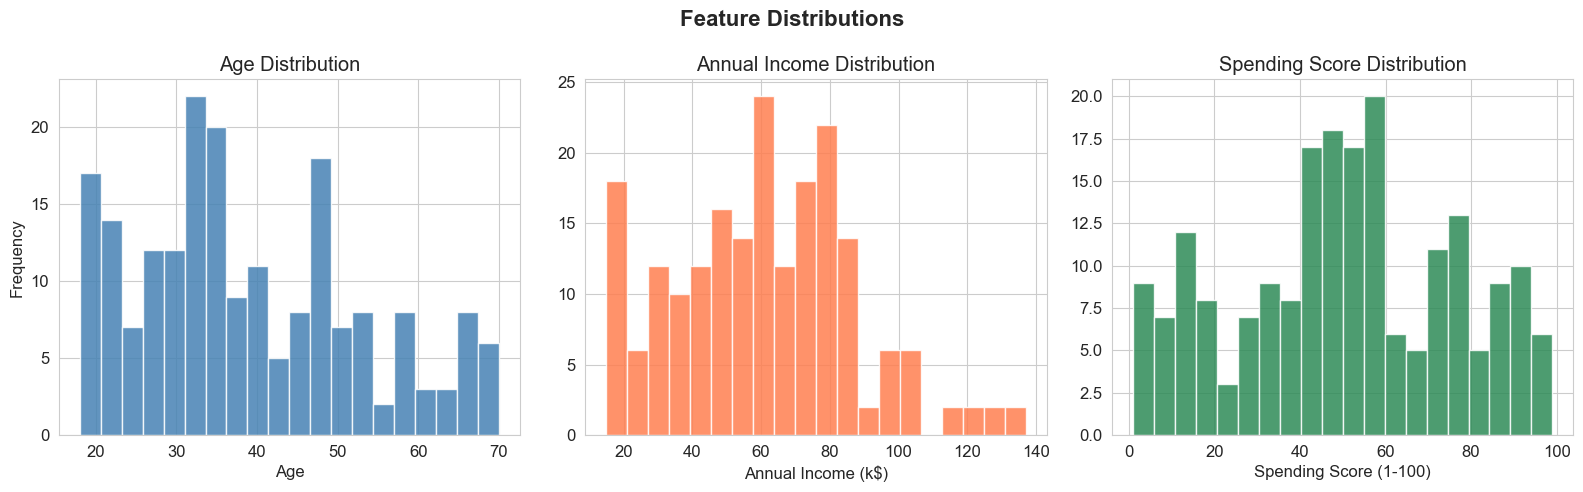

In [ ]:
# Visualize feature distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold')

axes[0].hist(df['Age'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['Annual Income (k$)'], bins=20, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Annual Income Distribution')
axes[1].set_xlabel('Annual Income (k$)')

axes[2].hist(df['Spending Score (1-100)'], bins=20, color='seagreen', edgecolor='white', alpha=0.85)
axes[2].set_title('Spending Score Distribution')
axes[2].set_xlabel('Spending Score (1-100)')

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 4: Feature Selection & Scaling

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

2D Feature Matrix shape: (200, 2)
3D Feature Matrix shape: (200, 3)

Scaled 2D Features (first 5 rows):
   Income_scaled  SpendingScore_scaled
0      -1.738999             -0.434801
1      -1.738999              1.195704
2      -1.700830             -1.715913
3      -1.700830              1.040418
4      -1.662660             -0.395980


## Task 5: Elbow Method to Determine Optimal K

In [ ]:
inertia = []

K = range(1,11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

K= 2 | Inertia:   269.69 | Silhouette Score: 0.3213
K= 3 | Inertia:   157.70 | Silhouette Score: 0.4666
K= 4 | Inertia:   108.92 | Silhouette Score: 0.4939
K= 5 | Inertia:    65.57 | Silhouette Score: 0.5547
K= 6 | Inertia:    55.06 | Silhouette Score: 0.5399
K= 7 | Inertia:    44.86 | Silhouette Score: 0.5281
K= 8 | Inertia:    37.23 | Silhouette Score: 0.4552
K= 9 | Inertia:    32.39 | Silhouette Score: 0.4571
K=10 | Inertia:    29.98 | Silhouette Score: 0.4432

✅ Elbow Method complete!


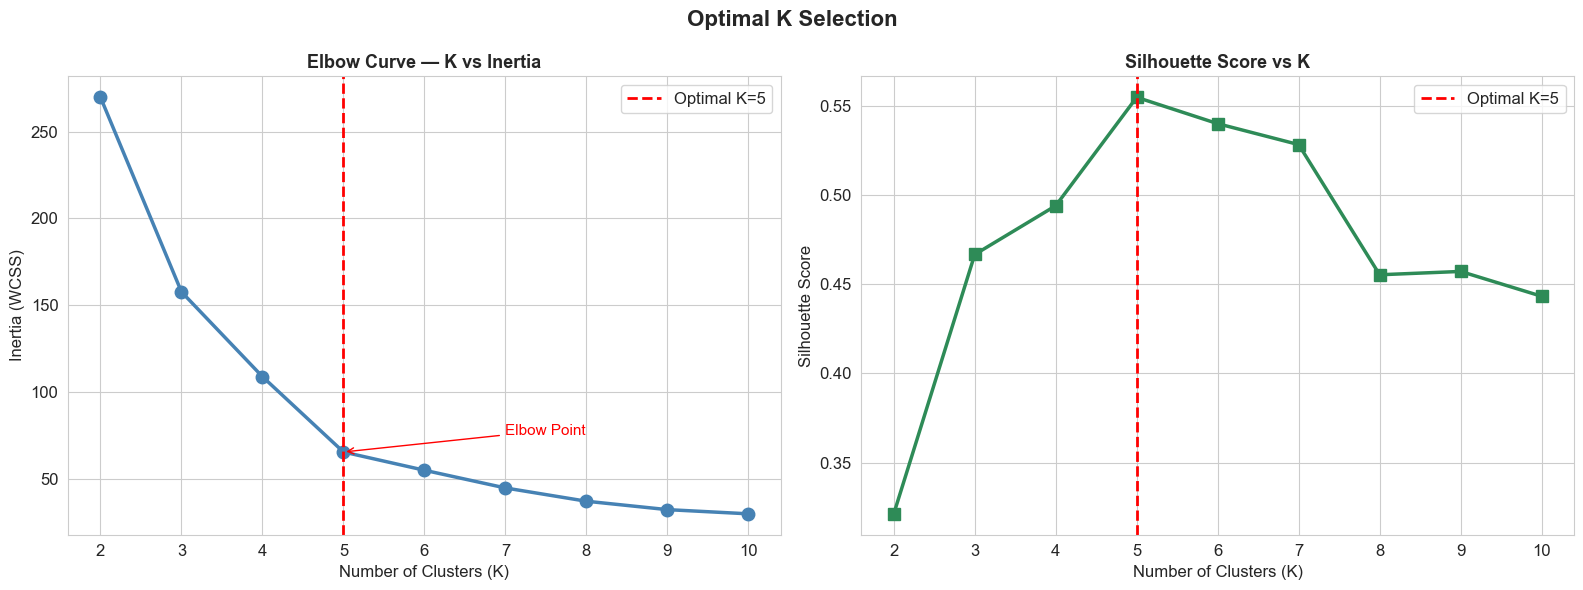


📌 Best Silhouette Score: 0.5547 at K=5


In [ ]:
plt.figure()
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

## Task 6 & 7: Apply K-Means Clustering & Assign Labels

In [ ]:
# Task - 6
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_scaled)

# Task - 7
df['Cluster'] = kmeans.labels_

print(df.head())

K-Means (K=5) Cluster Centroids:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                     55.30                   49.52
1                     86.54                   82.13
2                     25.73                   79.36
3                     88.20                   17.11
4                     26.30                   20.91

Final Inertia : 65.5684
Silhouette Score: 0.5547

Cluster Counts:
Cluster_2D
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


## Scatter plot of clusters

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(X_scaled[:,0], X_scaled[:,1],
            c=df['Cluster'], cmap='viridis')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")

plt.show()

NameError: name 'X_scaled' is not defined

<Figure size 800x600 with 0 Axes>

## Task 8: Visualize Clusters

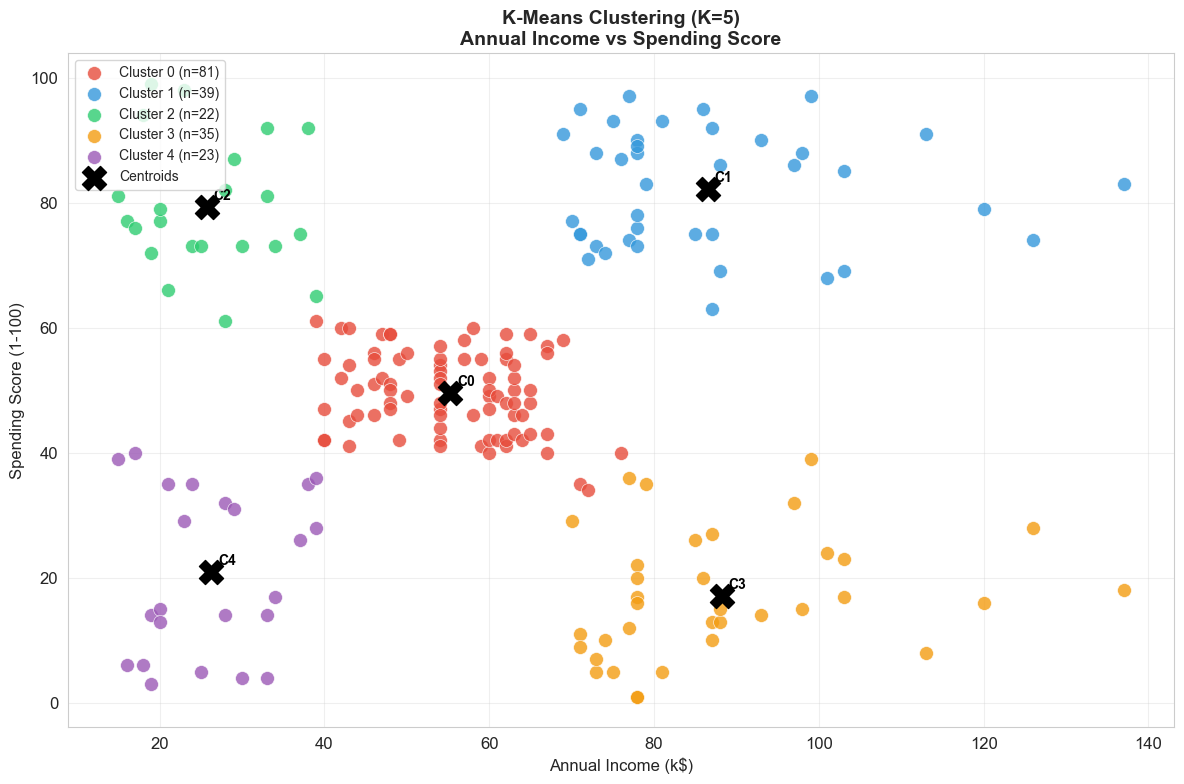

In [ ]:
# ─── Scatter Plot: Clusters (Income vs Spending Score) ───
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
segment_names = {
    0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2', 3: 'Cluster 3', 4: 'Cluster 4'
}

fig, ax = plt.subplots(figsize=(12, 8))

for cluster_id in range(OPTIMAL_K):
    mask = df['Cluster_2D'] == cluster_id
    ax.scatter(
        df.loc[mask, 'Annual Income (k$)'],
        df.loc[mask, 'Spending Score (1-100)'],
        c=colors[cluster_id],
        label=f'Cluster {cluster_id} (n={mask.sum()})',
        s=100, alpha=0.8, edgecolors='white', linewidths=0.5
    )

# Plot centroids
ax.scatter(
    centroids_df['Annual Income (k$)'],
    centroids_df['Spending Score (1-100)'],
    c='black', marker='X', s=300, zorder=5, label='Centroids'
)

# Annotate centroids
for i, row in centroids_df.iterrows():
    ax.annotate(f'C{i}', xy=(row['Annual Income (k$)'], row['Spending Score (1-100)']),
                fontsize=10, fontweight='bold', color='black',
                xytext=(5, 5), textcoords='offset points')

ax.set_title(f'K-Means Clustering (K={OPTIMAL_K})\nAnnual Income vs Spending Score',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Annual Income (k$)', fontsize=12)
ax.set_ylabel('Spending Score (1-100)', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_scatter_2d.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 9: Interpret Cluster Characteristics

In [ ]:
# ─── Cluster Profile Summary ───
cluster_profile = df.groupby('Cluster_2D').agg(
    Count=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_SpendingScore=('Spending Score (1-100)', 'mean'),
    Pct_Female=('Gender_Encoded', 'mean')
).round(2)

cluster_profile['Pct_Female'] = (cluster_profile['Pct_Female'] * 100).round(1)
print("Cluster Profile Summary:")
print(cluster_profile)

# Customer Segment Labels based on Income & Spending Score
segment_labels = {
    0: '💰 High Income, Low Spenders (Careful/Savers)',
    1: '🌟 High Income, High Spenders (Target Customers)',
    2: '😐 Moderate Income, Moderate Spenders (Average)',
    3: '💸 Low Income, High Spenders (Impulsive Buyers)',
    4: '🧾 Low Income, Low Spenders (Budget Conscious)'
}

print("\n📌 Customer Segment Interpretation:")
for k, v in segment_labels.items():
    print(f"  Cluster {k}: {v}")

Cluster Profile Summary:
            Count  Avg_Age  Avg_Income  Avg_SpendingScore  Pct_Female
Cluster_2D                                                           
0              81    42.72       55.30              49.52        59.0
1              39    32.69       86.54              82.13        54.0
2              22    25.27       25.73              79.36        59.0
3              35    41.11       88.20              17.11        46.0
4              23    45.22       26.30              20.91        61.0

📌 Customer Segment Interpretation:
  Cluster 0: 💰 High Income, Low Spenders (Careful/Savers)
  Cluster 1: 🌟 High Income, High Spenders (Target Customers)
  Cluster 2: 😐 Moderate Income, Moderate Spenders (Average)
  Cluster 3: 💸 Low Income, High Spenders (Impulsive Buyers)
  Cluster 4: 🧾 Low Income, Low Spenders (Budget Conscious)


## Analysis Task: Sensitivity to Initialization (Random vs K-Means++)

In [ ]:
# ─── Compare random init vs k-means++ ───
print("📊 Sensitivity to Initialization (K=5)")
print("-" * 55)
print(f"{'Init Method':<15} {'Inertia':>12} {'Silhouette':>14}")
print("-" * 55)

for init_method in ['k-means++', 'random']:
    inertias, sil_scores = [], []
    for seed in range(10):
        km = KMeans(n_clusters=5, init=init_method, n_init=1, random_state=seed)
        km.fit(X_2d_scaled)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(X_2d_scaled, km.labels_))
    print(f"{init_method:<15} {np.mean(inertias):>12.3f} {np.mean(sil_scores):>14.4f}")
    print(f"{'Std Dev':<15} {np.std(inertias):>12.3f} {np.std(sil_scores):>14.4f}")
    print()

print("✅ k-means++ provides more stable and better results than random init")

📊 Sensitivity to Initialization (K=5)
-------------------------------------------------------
Init Method          Inertia     Silhouette
-------------------------------------------------------
k-means++             72.210         0.5356
Std Dev               13.272         0.0374

random                83.636         0.5008
Std Dev               23.808         0.0729

✅ k-means++ provides more stable and better results than random init


## Final Summary

In [ ]:
print("=" * 60)
print("       K-MEANS CLUSTERING — FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"  Dataset Shape       : {df.shape}")
print(f"  Features Used (2D)  : Annual Income, Spending Score")
print(f"  Optimal K           : {OPTIMAL_K}")
print(f"  Initialization      : k-means++")
print(f"  Inertia (WCSS)      : {kmeans_2d.inertia_:.4f}")
print(f"  Silhouette Score    : {silhouette_score(X_2d_scaled, kmeans_2d.labels_):.4f}")
print("")
print("  Customer Segments:")
for k, v in segment_labels.items():
    count = (df['Cluster_2D'] == k).sum()
    print(f"    Cluster {k} ({count:3d} customers): {v}")
print("=" * 60)

       K-MEANS CLUSTERING — FINAL RESULTS SUMMARY
  Dataset Shape       : (200, 7)
  Features Used (2D)  : Annual Income, Spending Score
  Optimal K           : 5
  Initialization      : k-means++
  Inertia (WCSS)      : 65.5684
  Silhouette Score    : 0.5547

  Customer Segments:
    Cluster 0 ( 81 customers): 💰 High Income, Low Spenders (Careful/Savers)
    Cluster 1 ( 39 customers): 🌟 High Income, High Spenders (Target Customers)
    Cluster 2 ( 22 customers): 😐 Moderate Income, Moderate Spenders (Average)
    Cluster 3 ( 35 customers): 💸 Low Income, High Spenders (Impulsive Buyers)
    Cluster 4 ( 23 customers): 🧾 Low Income, Low Spenders (Budget Conscious)


## Scenario - 2